In [2]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
data=pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')

EXPLORATORY DATA ANALYSIS & DESCRIPTIVE STATISTICS

In [15]:
data.columns

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='str')

In [ ]:
data.duplicated().sum()

In [10]:
data.isna().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

In [11]:
data.columns=data.columns.str.replace(' ', '_')
data.columns

Index(['Person_ID', 'Gender', 'Age', 'Occupation', 'Sleep_Duration',
       'Quality_of_Sleep', 'Physical_Activity_Level', 'Stress_Level',
       'BMI_Category', 'Blood_Pressure', 'Heart_Rate', 'Daily_Steps',
       'Sleep_Disorder'],
      dtype='str')

In [12]:
print(data['BMI_Category'].unique())

<StringArray>
['Overweight', 'Normal', 'Obese', 'Normal Weight']
Length: 4, dtype: str


In [14]:
data['Sleep_Disorder']=data['Sleep_Disorder'].apply(lambda x: 0 if str(x).strip().lower() == 'none' or pd.isna(x) else 1)
data['Sleep_Disorder']

0      0
1      0
2      0
3      1
4      1
      ..
369    1
370    1
371    1
372    1
373    1
Name: Sleep_Disorder, Length: 374, dtype: int64

Numeric summary 

In [31]:
data.describe() 

,Person_ID,Age,Sleep_Duration,Quality_of_Sleep,Physical_Activity_Level,Stress_Level,Heart_Rate,Daily_Steps,Sleep_Disorder
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920,0.414439
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679,0.493285
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000,0.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000,0.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000,0.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000,1.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000,1.000000


Categorical summary

In [18]:
print("\n[NUMERIC VARIABLES KEY METRICS]")
print(data.describe().round(2))


[NUMERIC VARIABLES KEY METRICS]
       Person_ID     Age  Sleep_Duration  Quality_of_Sleep  \
count     374.00  374.00          374.00            374.00   
mean      187.50   42.18            7.13              7.31   
std       108.11    8.67            0.80              1.20   
min         1.00   27.00            5.80              4.00   
25%        94.25   35.25            6.40              6.00   
50%       187.50   43.00            7.20              7.00   
75%       280.75   50.00            7.80              8.00   
max       374.00   59.00            8.50              9.00   

       Physical_Activity_Level  Stress_Level  Heart_Rate  Daily_Steps  \
count                   374.00        374.00      374.00       374.00   
mean                     59.17          5.39       70.17      6816.84   
std                      20.83          1.77        4.14      1617.92   
min                      30.00          3.00       65.00      3000.00   
25%                      45.00          4.0

In [19]:
print("\n[CATEGORICAL VARIABLES OVERVIEW]")
print(data.describe(include=['object', 'str']))


[CATEGORICAL VARIABLES OVERVIEW]
       Gender Occupation BMI_Category Blood_Pressure
count     374        374          374            374
unique      2         11            3             25
top      Male      Nurse       Normal         130/85
freq      189         73          216             99


In [20]:
avg_sleep = data['Sleep_Duration'].mean()
print(f"\n* Key Metric: The average sleep duration across the sample is {avg_sleep:.2f} hours.")


* Key Metric: The average sleep duration across the sample is 7.13 hours.


VISUALIZATIONS

 GRAPH 1: Number of People with Each Sleep Disorder: This graph shows how many people have Insomnia, Sleep Apnea, or no sleep disorder.

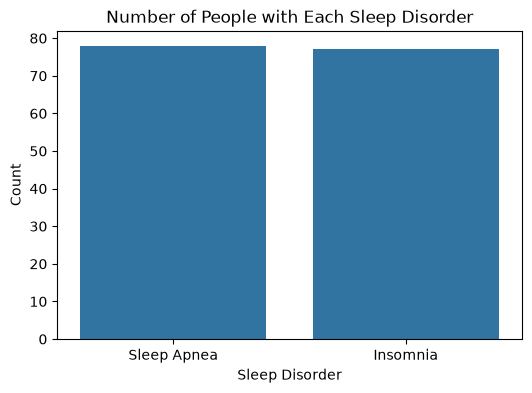

In [4]:

plt.figure(figsize=(6,4))

sns.countplot(data=data, x="Sleep Disorder")

plt.title("Number of People with Each Sleep Disorder")
plt.xlabel("Sleep Disorder")
plt.ylabel("Count")

plt.show()

GRAPH 2:Stress Level for Each Sleep Disorder: This helps us see whether people with sleep disorders tend to have higher stress


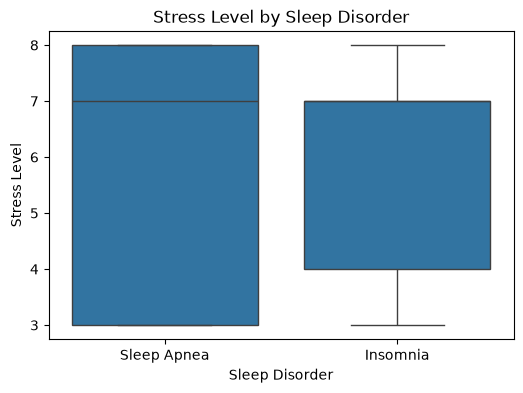

In [5]:

plt.figure(figsize=(6,4))

sns.boxplot(
    data=data,
    x="Sleep Disorder",
    y="Stress Level"
)

plt.title("Stress Level by Sleep Disorder")

plt.show()

GRAPH 3:Average Sleep Duration: Which group sleeps the longest?

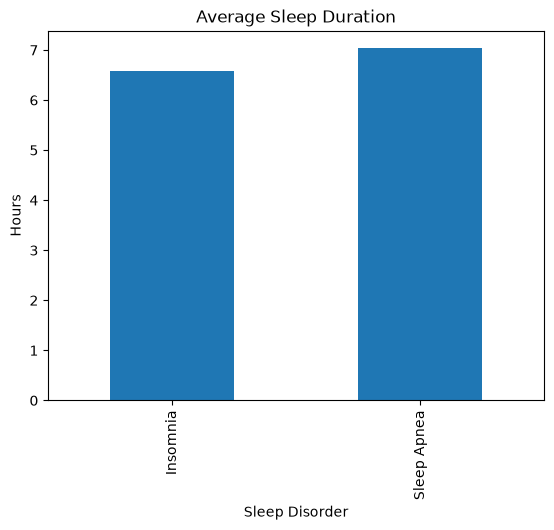

In [6]:


average_sleep = data.groupby("Sleep Disorder")["Sleep Duration"].mean()

average_sleep.plot(kind="bar")

plt.title("Average Sleep Duration")

plt.xlabel("Sleep Disorder")

plt.ylabel("Hours")

plt.show()

GRAPH 4:Average Stress Level

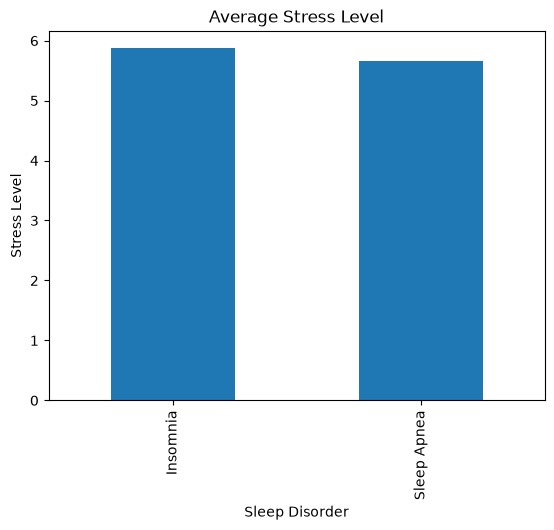

In [8]:


average_stress = data.groupby("Sleep Disorder")["Stress Level"].mean()

average_stress.plot(kind="bar")

plt.title("Average Stress Level")

plt.xlabel("Sleep Disorder")

plt.ylabel("Stress Level")

plt.show()

GRAPH 5: Sleep Quality vs Stress Level :We check whether higher stress is associated with poorer sleep quality.

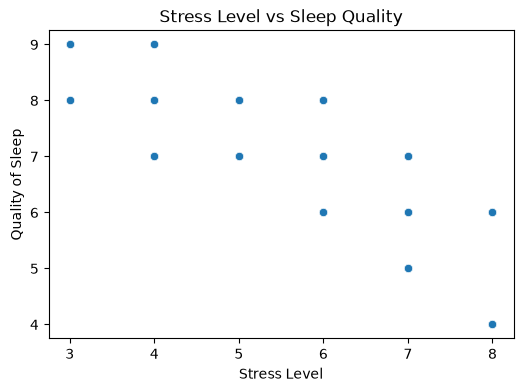

In [ ]:


plt.figure(figsize=(6,4))

sns.scatterplot(
    data=data,
    x="Stress Level",
    y="Quality of Sleep"
)

plt.title("Stress Level vs Sleep Quality")

plt.show()

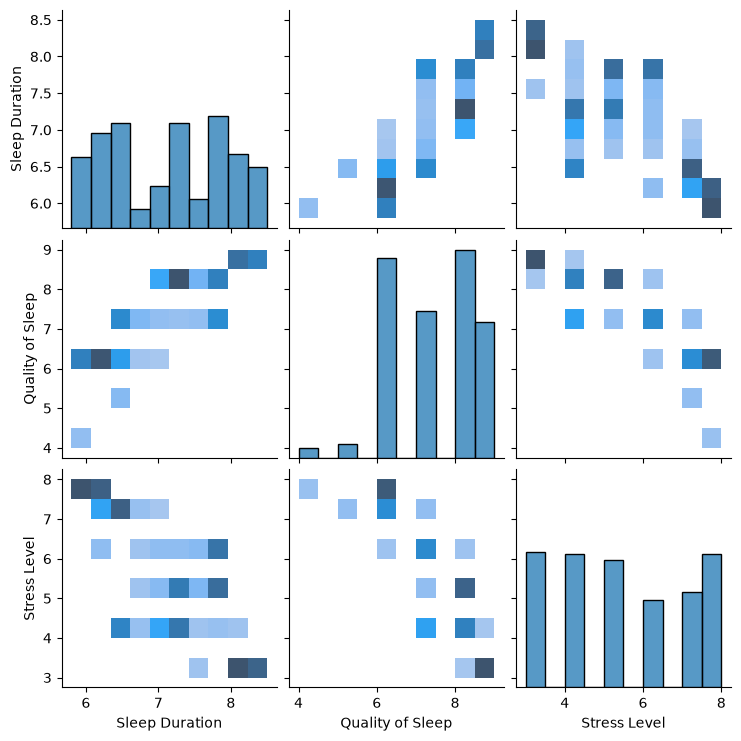

In [24]:

cols = ["Sleep Duration", "Quality of Sleep", "Stress Level"]
sns.pairplot(data[cols],kind='hist')

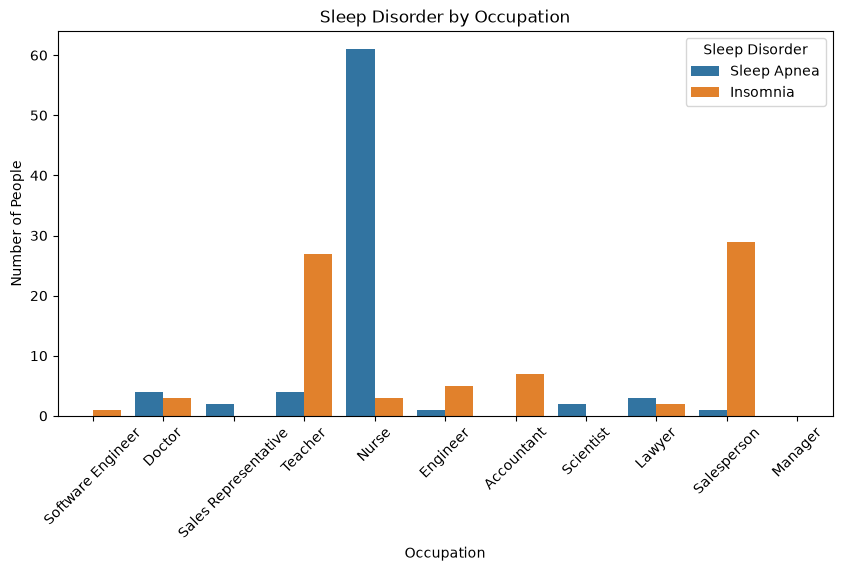

In [10]:
plt.figure(figsize=(10,5))

sns.countplot(data=data, x="Occupation", hue="Sleep Disorder")

plt.title("Sleep Disorder by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Number of People")

plt.xticks(rotation=45)

plt.show()